In [ ]:
!pip install pandas openpyxl numpy



In [13]:
import pandas as pd#for data manipulation and analysis
import matplotlib.pyplot as plt# For plotting graphs
import seaborn as sns # For advanced data visualization
import numpy as np#for numerical operations


#DATA_EXPLORATION
df=pd.read_excel("student_data.xlsx.xlsx")#loads the excel file into the pandas dataframe
df.head()#shows the first 5 rows of the dataset

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [14]:
df.info()#gives column names, data types,size, and missing values

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [15]:
# Display dataset size
df.shape
# Returns (number_of_rows, number_of_columns)

(395, 33)

In [16]:
pd.set_option('display.max_column',None)#shows all column

In [17]:
df.isnull().sum()#To check for missing values per column(0 shows no missing values in each column in the dataset)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [18]:
#Generate descriptive statistics for numerical features
df.describe()
#this shows the count(the number of non-missing values in that column), mean, std, min(the smallest value in a column),
#quartiles, and max(the largest value in that column)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [19]:
# Create Pass/Fail target variable
df["Pass"] = df["G3"].apply(lambda x: 1 if x >= 10 else 0)

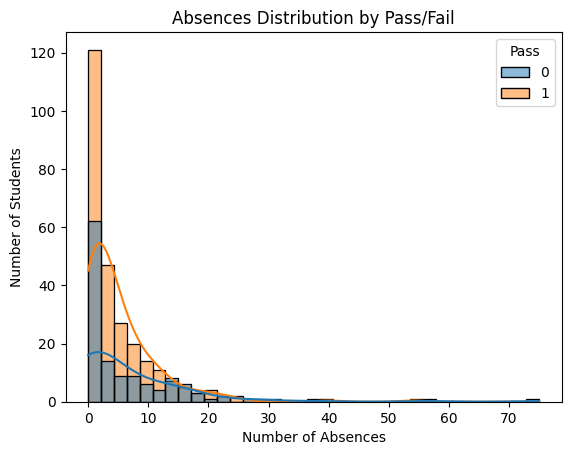

In [20]:
#visualization relationships between selected features and target variale(pass/fail)

# Create a histogram to show distribution of absences
sns.histplot(
    data=df,              # The dataset we are using
    x="absences",         # The column we want on the horizontal axis
    hue="Pass",           # Splits the histogram by Pass (0 = Fail, 1 = Pass)
    kde=True              # Adds a smooth curve to show data distribution trend
)

plt.title("Absences Distribution by Pass/Fail")  # Adds title to the graph
plt.xlabel("Number of Absences")                 # Label for x-axis
plt.ylabel("Number of Students")                 # Label for y-axis

plt.show()   # Displays the graph

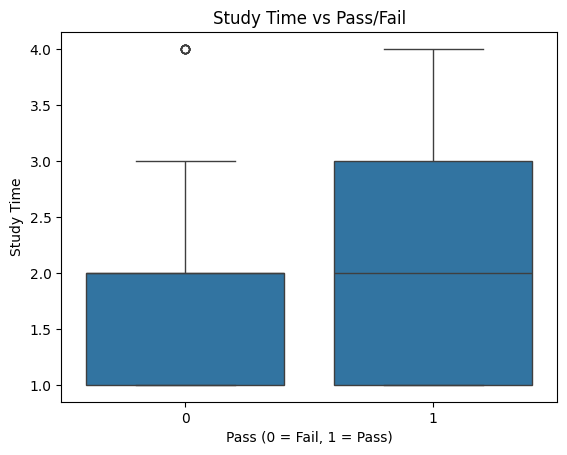

In [21]:
# Create a boxplot to compare study time for Pass and Fail students
sns.boxplot(
    x="Pass",        # Places Pass (0 and 1) on the horizontal axis
    y="studytime",   # Shows study time values on vertical axis
    data=df          # The dataset used
)

plt.title("Study Time vs Pass/Fail")   # Adds title
plt.xlabel("Pass (0 = Fail, 1 = Pass)") # Label x-axis
plt.ylabel("Study Time")                # Label y-axis

plt.show()   # Displays the graph


In [22]:
#DATA_CLEANING(handle missing values, duplicates, and outliers. Document all steps)
#HANDLING MISSING VLAUES
# Fill missing numerical values with median
for col in df.select_dtypes(include=np.number).columns:
   df[col].fillna(df[col].median(), inplace=True)
    # Replaces missing numerical values with median

# Fill missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
   df[col].fillna(df[col].mode()[0], inplace=True)  
    # Replaces missing categorical values with most frequent value

C:\Users\USER\AppData\Local\Temp\ipykernel_18680\2118142317.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_18680\2118142317.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usi

In [23]:
#REMOVING DUPLICATES 
df.duplicated()#identify duplicate rows(false shows no duplicates, ture shows duplicate)

0      False
1      False
2      False
3      False
4      False
       ...  
390    False
391    False
392    False
393    False
394    False
Length: 395, dtype: bool

In [25]:
df_unique= df.drop_duplicates()  #drops duplicate rows, modifies dataframe in place
print("Dataframe after removing duplicates:")
df_unique
# Removes duplicate rows 

Dataframe after removing duplicates:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,course,other,1,2,2,no,yes,yes,no,yes,yes,no,no,5,5,4,4,5,4,11,9,9,9,0
391,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,3,14,16,16,1
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7,0
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10,1


In [26]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1


In [27]:
df.tail(2)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10,1
394,MS,M,19,U,LE3,T,1,1,other,at_home,course,father,1,1,0,no,no,no,no,yes,yes,yes,no,3,2,3,3,3,5,5,8,9,9,0


In [28]:
df.isnull()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
391,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
392,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
393,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [30]:
#HANDLING OULIERS
# Calculate the first quartile (25th percentile)
Q1 = df['absences'].quantile(0.25)

# Calculate the third quartile (75th percentile)
Q3 = df['absences'].quantile(0.75)

# Compute the interquartile range
IQR = Q3 - Q1

# Define the lower and upper bounds for "normal" data
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outlier rows
outliers = df[(df['absences'] < lower_bound) | (df['absences'] > upper_bound)]
print(f"Number of outliers in absences: {len(outliers)}")

# Cap outliers at the upper bound (do nothing for lower bound since absences can't be negative)
df['absences'] = np.where(df['absences'] > upper_bound, upper_bound, df['absences'])
# (Lower bound might be negative, so we don't need to cap below zero)



Number of outliers in absences: 0


Documentation Of All Data Cleaning Steps.

Data cleaning was carried out to improve the quality, reliability, and consistency of the dataset before performing feature engineering and model training. These ar the preprocessing steps carried out to ensure the dataset was suitable for analysis.

1. Identification of Missing Values
The dataset was first examined to determine whether any columns contained missing values. Missing values occur when information is not recorded for certain observations and can negatively affect statistical analysis and machine learning models if not handled properly.

To identify missing values, the dataset was checked using the isnull().sum() function, which returns a summary of the number of missing values in each column.
This step helped determine whether further cleaning was required for numerical or categorical variables.

2. Handling Missing Numerical Values

For numerical variables, any missing values were replaced using the median of the respective column.

The median was chosen because it is less sensitive to extreme values (outliers) compared to the mean. This makes it a more reliable measure when filling missing data in real-world datasets.

Replacing missing numerical values ensured that the dataset remained complete without significantly altering the original data distribution.

3. Handling Missing Categorical Values

For categorical variables (text-based features such as gender, school type, or family characteristics), missing values were replaced using the mode.

The mode represents the most frequently occurring value in a column. Using the most common category ensures that missing values are filled in a way that preserves the overall distribution of the data.

This step ensured that categorical variables did not contain missing entries that could cause errors during model training.

4. Removal of Duplicate Records

Duplicate rows occur when the same observation appears more than once in a dataset. These duplicates can introduce bias into the analysis and lead to incorrect model training results.

To prevent this issue, duplicate records were identified and removed using the drop_duplicates() function. This ensured that each observation in the dataset represented a unique student record.

5. Detection and Handling of Outliers

Outliers are unusually large or small values that differ significantly from the rest of the data. These extreme values can distort statistical analysis and negatively affect the performance of machine learning models.

In this project, outliers in numerical variables such as absences were detected using the Interquartile Range (IQR) method. The IQR measures the spread of the middle 50% of the data and helps identify values that fall far outside the normal range.

Values that were significantly higher or lower than the acceptable range were removed from the dataset. This helped ensure that the dataset contained realistic and consistent values.

In [31]:
#FEATURE ENGINEERING( the process of transforming raw data into meaningful,informative,and actionable variables that enhance the performance, accuracy,and predictive power of machine learning models)
#grade category: Categorise final grades into Low (0-9), Medium (10-14), High (15-20)
def grade_category(grade):
    if grade <= 9:
        return "Low"
    elif grade <= 14:
        return "Medium"
    else:
        return "High"

df["Grade_Category"] = df["G3"].apply(grade_category)
# Applies the function to each G3 value

# Display first 5 rows to confirm new column
print("\nGrade Category Column Created Successfully:")
print(df[["G3", "Grade_Category"]].head())


Grade Category Column Created Successfully:
   G3 Grade_Category
0   6            Low
1   6            Low
2  10         Medium
3  15           High
4  10         Medium


In [32]:
# Attendance Status: Convert absence counts into Regular or Irregular.
df["Attendance_Status"] = df["absences"].apply(
    lambda x: "Regular" if x <= 10 else "Irregular"
)

# Display first 5 rows to confirm
print("\nAttendance Status Column Created Successfully:")
print(df[["absences", "Attendance_Status"]].head())

#Diaplay last 5 rows to confirm
print(df[["absences", "Attendance_Status"]].tail())


Attendance Status Column Created Successfully:
   absences Attendance_Status
0       6.0           Regular
1       4.0           Regular
2      10.0           Regular
3       2.0           Regular
4       4.0           Regular
     absences Attendance_Status
390      11.0         Irregular
391       3.0           Regular
392       3.0           Regular
393       0.0           Regular
394       5.0           Regular


In [33]:
# Study Load Feature: Combine weekly study time and number of past failures.
df["Study_Load"] = df["studytime"] + df["failures"]

# Display first 5 rows to confirm
print("\nStudy Load Column Created Successfully:")
print(df[["studytime", "failures", "Study_Load"]].head())



Study Load Column Created Successfully:
   studytime  failures  Study_Load
0          2         0           2
1          2         0           2
2          2         3           5
3          3         0           3
4          2         0           2


In [34]:
# Target Variable: Create binary Pass/Fail based on final grade (G3 >= 10).
df["Pass"] = df["G3"].apply(lambda x: 1 if x >= 10 else 0)
# Creates binary variable: 1 = Pass, 0 = Fail

print("Target Variable 'Pass' Created Successfully!")

# Show first 10 rows of G3 and Pass columns
print(df[["G3", "Pass"]].head(10))

# Show how many students passed and failed
print("\nPass/Fail Distribution:")
print(df["Pass"].value_counts())# counts how many times each values appears.

Target Variable 'Pass' Created Successfully!
   G3  Pass
0   6     0
1   6     0
2  10     1
3  15     1
4  10     1
5  15     1
6  11     1
7   6     0
8  19     1
9  15     1

Pass/Fail Distribution:
Pass
1    265
0    130
Name: count, dtype: int64


In [35]:
#DATA TRANSFORMATION(Converting data from one structure or format to another)(converting to fully numeric format suitable for machine learning.)
#Label encode categorical variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()  # Create encoder object

# Encode all categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    # Converts text categories into numeric labels

print("Categorical Columns Encoded Successfully!")

# Show first 5 rows to confirm encoding
df.head()


Categorical Columns Encoded Successfully!


C:\Users\USER\AppData\Local\Temp\ipykernel_18680\3011847938.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass,Grade_Category,Attendance_Status,Study_Load
0,0,0,18,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6.0,5,6,6,0,1,1,2
1,0,0,17,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4.0,5,5,6,0,1,1,2
2,0,0,15,1,1,1,1,1,0,2,2,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10.0,7,8,10,1,2,1,5
3,0,0,15,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2.0,15,14,15,1,0,1,3
4,0,0,16,1,0,1,3,3,2,2,1,0,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4.0,6,10,10,1,2,1,2


In [36]:
# Scale numerical features (Min-Max or Standard scaling)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # Create scaler object

# Select features (exclude target column)
X = df.drop("Pass", axis=1)  # Features
y = df["Pass"]               # Target

X_scaled = scaler.fit_transform(X)
# Standardizes numerical features (mean=0, std=1)

print("Feature Scaling Completed Successfully!")

# Convert scaled data back to DataFrame for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Show first 5 rows of scaled data
X_scaled_df.head()

#Now x_scaled is ready for modelling.

Feature Scaling Completed Successfully!


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Grade_Category,Attendance_Status,Study_Load
0,-0.36305,-0.948176,1.023046,0.535392,-0.636941,-2.938392,1.143856,1.360371,-1.769793,1.993149,-1.040599,0.273945,0.792251,-0.042286,-0.449944,2.597133,-1.257656,-0.919671,-1.017881,0.507899,0.23094,-2.232677,-0.708450,0.062194,-0.236010,0.801479,-0.540699,-1.003789,-0.399289,0.142892,-1.782467,-1.254791,-0.964934,-0.395539,0.447893,-0.362780
1,-0.36305,-0.948176,0.238380,0.535392,-0.636941,0.340322,-1.600009,-1.399970,-1.769793,-0.325831,-1.040599,-1.591714,-0.643249,-0.042286,-0.449944,-0.385040,0.795130,-0.919671,-1.017881,-1.968894,0.23094,0.447893,-0.708450,1.178860,-0.236010,-0.097908,-0.540699,-1.003789,-0.399289,-0.208773,-1.782467,-1.520979,-0.964934,-0.395539,0.447893,-0.362780
2,-0.36305,-0.948176,-1.330954,0.535392,1.570004,0.340322,-1.600009,-1.399970,-1.769793,-0.325831,0.616806,0.273945,-0.643249,-0.042286,3.589323,2.597133,-1.257656,1.087346,-1.017881,0.507899,0.23094,0.447893,-0.708450,0.062194,-0.236010,-0.997295,0.583385,0.551100,-0.399289,0.846221,-1.179147,-0.722415,-0.090739,0.917384,0.447893,2.581703
3,-0.36305,-0.948176,-1.330954,0.535392,-0.636941,0.340322,1.143856,-0.479857,-0.954077,0.833659,-0.211896,0.273945,-0.643249,1.150779,-0.449944,-0.385040,0.795130,1.087346,0.982433,0.507899,0.23094,0.447893,1.411533,-1.054472,-1.238419,-0.997295,-0.540699,-1.003789,1.041070,-0.560438,1.234133,0.874715,1.002004,-1.708462,0.447893,0.618714
4,-0.36305,-0.948176,-0.546287,0.535392,-0.636941,0.340322,0.229234,0.440257,-0.138362,-0.325831,-0.211896,-1.591714,-0.643249,-0.042286,-0.449944,-0.385040,0.795130,1.087346,-1.017881,0.507899,0.23094,-2.232677,-0.708450,0.062194,-0.236010,-0.997295,-0.540699,-0.226345,1.041070,-0.208773,-1.480807,-0.190038,-0.090739,0.917384,0.447893,-0.362780


In [37]:
# Check data types after transformation(if it's now transformed to numeric)
print("Final Data Types:")
print(df.dtypes)
print("Data Transformation Confirmed.")

Final Data Types:
school                 int64
sex                    int64
age                    int64
address                int64
famsize                int64
Pstatus                int64
Medu                   int64
Fedu                   int64
Mjob                   int64
Fjob                   int64
reason                 int64
guardian               int64
traveltime             int64
studytime              int64
failures               int64
schoolsup              int64
famsup                 int64
paid                   int64
activities             int64
nursery                int64
higher                 int64
internet               int64
romantic               int64
famrel                 int64
freetime               int64
goout                  int64
Dalc                   int64
Walc                   int64
health                 int64
absences             float64
G1                     int64
G2                     int64
G3                     int64
Pass                   in

In [39]:
#MODEL PREPARATION AND COMPARISON
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



# Split dataset into training (70%) and testing (30%) sets with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, # scaled feature
    y,        # target variable
    test_size=0.3,# 30% for testing
    random_state=42,# ensures reproducibiliy
    stratify=y# maintains the original class distriution of pass and fail when splitting the data(makes sure the training and testing set have similar proportions of pass and fail students)
)
# Print dataset sizes
print("Train-Test Split Completed Successfully!")
print("Training Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)


Train-Test Split Completed Successfully!
Training Set Size: (276, 36)
Testing Set Size: (119, 36)


In [43]:
# Logistic Regression
lr = LogisticRegression()

lr.fit(X_train, y_train)
# Trains logistic regression model

lr_pred = lr.predict(X_test)
# Makes predictions

# Logistic Regression Evaluation(model evaluation)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9831932773109243
[[39  0]
 [ 2 78]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        39
           1       1.00      0.97      0.99        80

    accuracy                           0.98       119
   macro avg       0.98      0.99      0.98       119
weighted avg       0.98      0.98      0.98       119



In [44]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
# Trains decision tree model

dt_pred = dt.predict(X_test)# makes prediction

# Decision Tree Evaluation(model evaluation)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 1.0
[[39  0]
 [ 0 80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        80

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119



In [103]:
#Rain Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
# Trains random forest model

rf_pred = rf.predict(X_test)# makes prediction

# Random Forest Evaluation(model evaluation)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0
[[39  0]
 [ 0 80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        80

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119



In [107]:
#Model Comparison
# Compare models based on accuracy, interpretability, and computational complexity.
# We can create a summary DataFrame
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, lr_pred),
                 accuracy_score(y_test, dt_pred),
                 accuracy_score(y_test, rf_pred)],
    # You can add more metrics like F1-score from classification report
})
print("\nComparison Summary:")
print(results)


Comparison Summary:
                 Model  Accuracy
0  Logistic Regression  0.983193
1        Decision Tree  1.000000
2        Random Forest  1.000000


In [108]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Prepare lists to store results
results_list = []

# 1. Logistic Regression
start_time = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_time = time.time() - start_time
y_pred_lr = lr.predict(X_test)

# Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Complexity: number of coefficients (including intercept)
lr_complexity = lr.coef_.shape[1] + 1   # features + intercept

results_list.append({
    'Model': 'Logistic Regression',
    'Accuracy': acc_lr,
    'Precision': prec_lr,
    'Recall': rec_lr,
    'F1-Score': f1_lr,
    'Interpretability': 'High (coefficients)',
    'Complexity (params)': lr_complexity,
    'Training Time (s)': lr_time
})

# 2. Decision Tree
start_time = time.time()
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_time = time.time() - start_time
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Complexity: tree depth and number of leaves
dt_depth = dt.get_depth()
dt_leaves = dt.get_n_leaves()
dt_complexity = f"depth={dt_depth}, leaves={dt_leaves}"

results_list.append({
    'Model': 'Decision Tree',
    'Accuracy': acc_dt,
    'Precision': prec_dt,
    'Recall': rec_dt,
    'F1-Score': f1_dt,
    'Interpretability': 'High (tree structure)',
    'Complexity (depth/leaves)': dt_complexity,
    'Training Time (s)': dt_time
})

# 3. Random Forest
start_time = time.time()
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
rf_time = time.time() - start_time
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Complexity: number of trees and average depth
rf_n_trees = rf.n_estimators
# Average depth across trees (could be heavy to compute, but we can approximate)
avg_depth = np.mean([tree.get_depth() for tree in rf.estimators_])
rf_complexity = f"trees={rf_n_trees}, avg_depth={avg_depth:.1f}"

results_list.append({
    'Model': 'Random Forest',
    'Accuracy': acc_rf,
    'Precision': prec_rf,
    'Recall': rec_rf,
    'F1-Score': f1_rf,
    'Interpretability': 'Low (ensemble)',
    'Complexity (trees/depth)': rf_complexity,
    'Training Time (s)': rf_time
})

# Create comparison DataFrame
comparison_df = pd.DataFrame(results_list)
print("\nModel Comparison Summary:")
print(comparison_df.to_string(index=False))


Model Comparison Summary:
              Model  Accuracy  Precision  Recall  F1-Score      Interpretability  Complexity (params)  Training Time (s) Complexity (depth/leaves) Complexity (trees/depth)
Logistic Regression  0.983193        1.0   0.975  0.987342   High (coefficients)                 37.0           0.025197                       NaN                      NaN
      Decision Tree  1.000000        1.0   1.000  1.000000 High (tree structure)                  NaN           0.007553         depth=1, leaves=2                      NaN
      Random Forest  1.000000        1.0   1.000  1.000000        Low (ensemble)                  NaN           0.713518                       NaN trees=100, avg_depth=5.0
